Make a GIF of the fields on a slice along the middle of the TL 

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
# parser = argparse.ArgumentParser()

from PIL import Image

In [2]:
def fetchVectorData(file_template, field='e'):
    # field can be either 'e','h', or 's' (Poynting vector)
    data = {} # dict for x,y,z arrays
    for c in ['x','y','z']:
        filename = file_template.format(field,c)
        # print(f'Reading {filename} ...')
        f = h5py.File(filename)
        data[f'{field}{c}'] = np.array(f[f'{field}{c}'])

    u = data[f'{field}x']
    v = data[f'{field}y']
    w = data[f'{field}z']
    return u,v,w

In [3]:
def readDataset(dir,start,stop, prefix="run"):
    data_series = []
    
    # test input 
    # dir = "./h5_files/demo_speed_of_light_and_wavelength"

    # for t in range(10,24):
    for t in range(start,stop+1):
    # for t in range(1,28+1):
        if t<10:
            t = '0'+str(t)
        # file_template = "./h5_files/run-{}{}-0000__TIME__.00.h5".replace("__TIME__",str(t))
        # file_template = "./h5_files/demo_speed_of_light_and_wavelength-{}{}-0000__TIME__.00.h5".replace("__TIME__",str(t))
        # file_template = "./h5_files_demo_calibration/run-{}{}-0000__TIME__.00.h5".replace("__TIME__",str(t))
        # file_template = "./h5_files/run_demo-{}{}-0000__TIME__.00.h5".replace("__TIME__",str(t))
        
        file_template = dir + "/" + prefix + "-{}{}-0000__TIME__.00.h5"
        file_template = file_template.replace("__TIME__",str(t)) # crude but works
        # print(file_template)
        u,v,w = fetchVectorData(file_template,field='e')
        # data_series.append(v[:,int(235/2),:])


        # we want mp.Ez, which is 'w' here
        # Cut along middle of y index range
        _mid = int(w.shape[1]/2)
        data_series.append(w[:,_mid,:])  # new geometry is smaller
    
    return data_series

In [4]:
# _ = readDataset("./h5_files",1,30,prefix="demo_speed_of_light_and_wavelength")

# Conclusions


## Source settings
1. `source_wavelength` is indeed equal to the value that we enter (in microns)
2. Speed of light here really is ~7um/7sec = 1 (um/sec)
3. `resolution=10` seems adequate
4. For a Gaussian source the `width` setting controls the spatial width of pulse.
5. Gaussian source can freeze the field shapes in the source region for time instants after the time specified by the `cutoff` parameter. 

NOTE: Should be longer than a few wavelengths for a properly modulated Gaussian wavepacket!

In [9]:
# NOTE: Can cause kernel crash
data_series = readDataset("./h5_files_demo",10,13,prefix="run_demo")
# data_series = readDataset(".",1,20, prefix="run_demo") # use for partial runs

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = './h5_files_demo/run_demo-ex-000010.00.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

NameError: name 'data_series' is not defined

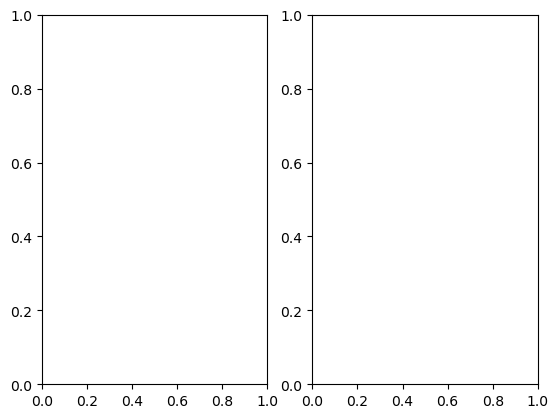

In [6]:
# Plot just a snapshot
# t_vals = list(range(1,60+1))
k = 20-10 # time instant in seconds

fig, axes = plt.subplots(1,2)
axes[0].imshow(data_series[k])
# axes[0].title(f'Time = {k}')
axes[1].plot(data_series[k][:,70])
axes[1].grid()#(data_series[k][:,70])
# axes[1].title(f'Slice along y=0, time = {k}')

Text(0.5, 1.0, 'TIme = 15')

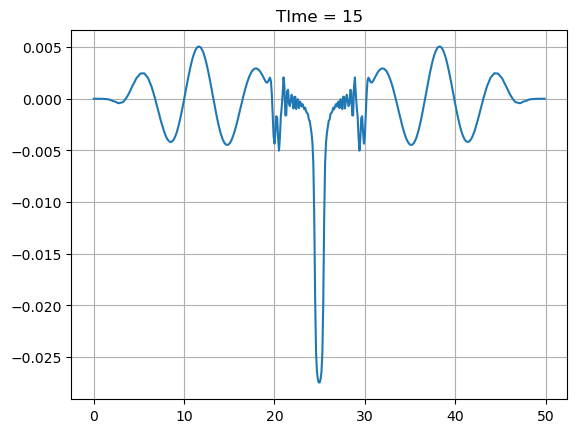

In [21]:
k = 15
y = data_series[k][:,70]
_resolution = 10
_xvals = [k/10 for k in list(range(len(y)))]
plt.plot(_xvals,y); plt.grid()
plt.title(f'TIme = {k}')

1D slice animation

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Parameters
slice_row = 75  # Row to slice for the 1D visualization
frames_1d = []

for i, data in enumerate(data_series):
    # Create a figure for the 1D slice
    fig, ax = plt.subplots(figsize=(6, 4))
    # ax.plot(data[:, slice_row], color='blue', marker='o', label=f"Frame {i+1}")
    ax.plot(data[:, slice_row], color='blue', label=f"Frame {i+1}")
    ax.set_title(f"1D Slice - Row {slice_row}")
    ax.set_xlabel("Index")
    ax.set_ylabel("Value")
    _lim = 30e-3
    ax.set_ylim(-_lim, _lim)  # Adjust based on the data range
    ax.legend()
    ax.grid(True)

    # Save the figure to a buffer
    fig.canvas.draw()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    frames_1d.append(Image.fromarray(image))

    plt.close(fig)

# Save the 1D slice GIF
frames_1d[0].save(
    'h5_files_demo/fields_1D.gif',
    save_all=True,
    append_images=frames_1d[1:],
    duration=200,  # Duration in milliseconds between frames
    loop=0  # 0 for infinite loop
)

print("GIF saved as 'h5_files_demo/fields_1D.gif'.")


/tmp/ipykernel_883842/2984295820.py:24: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')


GIF saved as 'h5_files_demo/fields_1D.gif'.
